<a href="https://colab.research.google.com/github/LilyVyhanek-um/SIADS-593-Project/blob/main/Milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

1. Load Datasets

In [ ]:
data_path = '/content/drive/MyDrive/Colab Notebooks/Sample Synthetic Patient Record'

# 1. PATIENTS: Patient Demographics Baseline Table
patients_df = pd.read_csv(os.path.join(data_path, 'patients.csv'))
# 2. ENCOUNTERS: Clinical Healthcare Utilization & Cost Log
encounters_df = pd.read_csv(os.path.join(data_path, 'encounters.csv'))
# 3. MEDICATIONS: Prescription Orders & Pharmaceutical Burdens
medications_df = pd.read_csv(os.path.join(data_path, 'medications.csv'))
# 4. CONDITIONS: Confirmed Clinical Diagnoses
conditions_df = pd.read_csv(os.path.join(data_path, 'conditions.csv'))

2. Perform Data Cleaning & Preprocessing

2.1 Initial Data Preprocessing



In [ ]:
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
# 1. The exact date/time when a patient checked into the hospital.
encounters_df['START'] = pd.to_datetime(encounters_df['START'])
# 2. The exact date when a prescription drug was prescribed/started.
medications_df['START'] = pd.to_datetime(medications_df['START'])
# 3. The exact date when a patient was officially diagnosed with a disease.
conditions_df['START'] = pd.to_datetime(conditions_df['START'])

# Compute baseline age at the end of the feature window (Year 2020)
patients_df['AGE_2020'] = 2020 - patients_df['BIRTHDATE'].dt.year
patients_clean = patients_df[['Id', 'AGE_2020', 'GENDER', 'RACE']].copy()
patients_clean.rename(columns={'Id': 'PATIENT_ID'}, inplace=True)

2.2 Historical Feature Construction (X-Variables: 2019-2020)

In [ ]:
# Filter historical medical records for years 2019 and 2020
enc_hist = encounters_df[encounters_df['START'].dt.year.isin([2019, 2020])].copy()
med_hist = medications_df[medications_df['START'].dt.year.isin([2019, 2020])].copy()
cond_hist = conditions_df[conditions_df['START'].dt.year.isin([2019, 2020])].copy()

# Aggregate baseline healthcare utilization and total cost metrics
enc_summary_hist = enc_hist.groupby('PATIENT').agg(
    HIST_TOTAL_ENCOUNTERS=('Id', 'size'),
    HIST_TOTAL_EXPENSES=('TOTAL_CLAIM_COST', 'sum'),
    HIST_TOTAL_COVERAGE=('PAYER_COVERAGE', 'sum')
).reset_index()

# Derive absolute historical out-of-pocket (OOP) financial burden
enc_summary_hist['HIST_TOTAL_OOP'] = enc_summary_hist['HIST_TOTAL_EXPENSES'] - enc_summary_hist['HIST_TOTAL_COVERAGE']

In [ ]:
# Aggregate clinical event volumes and clinical burdens
emergency_hist = enc_hist[enc_hist['ENCOUNTERCLASS'] == 'emergency'].groupby('PATIENT').size().reset_index(name='HIST_EMERGENCY_VISITS')
med_counts_hist = med_hist.groupby('PATIENT').size().reset_index(name='HIST_MEDICATION_COUNT')
condition_counts_hist = cond_hist.groupby('PATIENT').size().reset_index(name='HIST_CONDITION_COUNT')

# Generate Multi-Label binary matrix for Top 10 clinical conditions
top_conds = cond_hist['DESCRIPTION'].value_counts().head(10).index.tolist()
cond_pivot_hist = cond_hist[cond_hist['DESCRIPTION'].isin(top_conds)].pivot_table(
    index='PATIENT', columns='DESCRIPTION', aggfunc='size', fill_value=0
)
cond_pivot_hist = (cond_pivot_hist > 0).astype(int).add_prefix('Hist_Condition_')

# Generate Multi-Label binary matrix for Top 10 prescribed medications
top_meds = med_hist['DESCRIPTION'].value_counts().head(10).index.tolist()
med_pivot_hist = med_hist[med_hist['DESCRIPTION'].isin(top_meds)].pivot_table(
    index='PATIENT', columns='DESCRIPTION', aggfunc='size', fill_value=0
)
med_pivot_hist = (med_pivot_hist > 0).astype(int).add_prefix('Hist_Medication_')

2.3 Future Target Construction (Y-Variables: 2021)

In [ ]:
# Filter future utilization logs restricted strictly to the year 2021
enc_2021 = encounters_df[encounters_df['START'].dt.year == 2021].copy()

# Calculate actual 2021 annualized total medical claim expenses
enc_summary_2021 = enc_2021.groupby('PATIENT').agg(
    EXPENSES_2021=('TOTAL_CLAIM_COST', 'sum'),
    ENCOUNTERS_2021=('Id', 'size')
).reset_index()

2.4 Data Merge & Imputation

In [ ]:
# Initialize core profile dataframe with static demographics
profile_df = patients_clean.copy()

# Consolidate historical features and future target tables
tables_to_merge = [
    enc_summary_hist, emergency_hist, med_counts_hist, condition_counts_hist,
    cond_pivot_hist, med_pivot_hist,
    enc_summary_2021
]

for table in tables_to_merge:
    profile_df = profile_df.merge(
        table,
        left_on='PATIENT_ID',
        right_index=(table.index.name == 'PATIENT'),
        right_on=None if table.index.name == 'PATIENT' else 'PATIENT',
        how='left'
    )
    profile_df.drop(columns=['PATIENT'], errors='ignore', inplace=True)

In [ ]:
hist_fill_cols = ['HIST_TOTAL_ENCOUNTERS', 'HIST_TOTAL_EXPENSES', 'HIST_TOTAL_COVERAGE', 'HIST_TOTAL_OOP', 'HIST_EMERGENCY_VISITS', 'HIST_MEDICATION_COUNT', 'HIST_CONDITION_COUNT']
future_fill_cols = ['EXPENSES_2021', 'ENCOUNTERS_2021']
clinical_cols = [col for col in profile_df.columns if col.startswith('Hist_Condition_') or col.startswith('Hist_Medication_')]

profile_df[hist_fill_cols] = profile_df[hist_fill_cols].fillna(0)
profile_df[future_fill_cols] = profile_df[future_fill_cols].fillna(0)
profile_df[clinical_cols] = profile_df[clinical_cols].fillna(0).astype(int)

2.5 High-level feature Engineering

In [ ]:
# Establish high-cost threshold using the 80th percentile of 2021 expenses
high_cost_threshold = profile_df['EXPENSES_2021'].quantile(0.80)

# Generate the primary binary classification target variable for supervised ML
profile_df['IS_HIGH_COST_2021'] = (profile_df['EXPENSES_2021'] >= high_cost_threshold).astype(int)

# Segment patients into 3 equal-sized historical baseline utilization tiers
profile_df['HIST_UTILIZATION_TIER'] = pd.qcut(
    profile_df['HIST_TOTAL_ENCOUNTERS'].rank(method='first'),
    q=3,
    labels=['Low Utilizer', 'Mid Utilizer', 'High Utilizer']
)

profile_df.head()

,PATIENT_ID,AGE_2020,GENDER,RACE,HIST_TOTAL_ENCOUNTERS,HIST_TOTAL_EXPENSES,HIST_TOTAL_COVERAGE,HIST_TOTAL_OOP,HIST_EMERGENCY_VISITS,HIST_MEDICATION_COUNT,...,Hist_Medication_Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray,Hist_Medication_Simvastatin 10 MG Oral Tablet,Hist_Medication_Simvastatin 20 MG Oral Tablet,Hist_Medication_amLODIPine 2.5 MG Oral Tablet,Hist_Medication_insulin human isophane 70 UNT/ML / Regular Insulin Human 30 UNT/ML Injectable Suspension [Humulin],Hist_Medication_lisinopril 10 MG Oral Tablet,EXPENSES_2021,ENCOUNTERS_2021,IS_HIGH_COST_2021,HIST_UTILIZATION_TIER
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,1,M,white,10.0,7281.28,6803.22,478.06,0.0,2.0,...,0,0,0,0,0,0,1222.01,2.0,0,High Utilizer
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,15,F,white,3.0,2493.87,0.00,2493.87,1.0,1.0,...,0,0,0,0,0,0,8248.49,3.0,0,Mid Utilizer
2,339144f8-50e1-633e-a013-f361391c4cff,22,M,white,2.0,1994.22,0.00,1994.22,0.0,6.0,...,0,0,0,1,0,1,1325.69,3.0,0,Low Utilizer
3,d488232e-bf14-4bed-08c0-a82f34b6a197,17,F,white,12.0,178139.01,103636.80,74502.21,1.0,0.0,...,0,0,0,0,0,0,46267.52,6.0,1,High Utilizer
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,27,M,black,1.0,786.33,0.00,786.33,0.0,0.0,...,0,0,0,0,0,0,0.00,0.0,0,Low Utilizer


3. Initial Analysis

3.1 Simple Analysis: Demographic Baseline - Age Distribution Profiling

This section profiles the age distribution of the 1,163-patient cohort using the AGE_2020 variable, which represents each patient's age as of the end of the historical feature window (year 2020). Patient ages are binned into five clinical age groups (<18, 18–34, 35–49, 50–64, 65+) for downstream stratification. A histogram overlaid with a KDE curve is used to visualize the shape of the distribution, with a median line added as a central tendency reference.



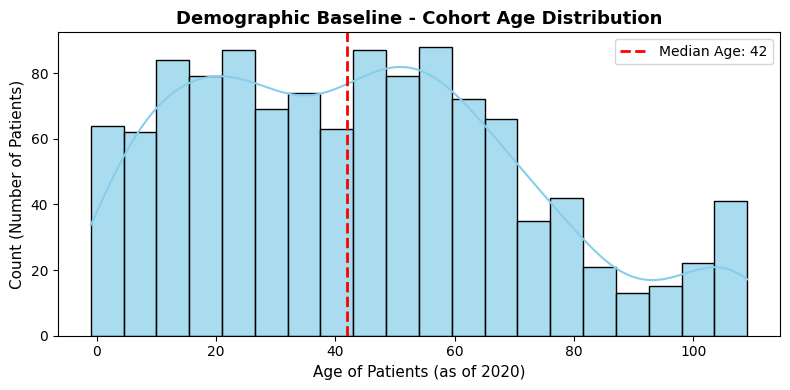

In [ ]:
profile_df['Age_Group'] = pd.cut(
    profile_df['AGE_2020'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['<18', '18-34', '35-49', '50-64', '65+']
)

plt.figure(figsize=(8, 4))
sns.histplot(
    data=profile_df,
    x='AGE_2020',
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

median_age = profile_df['AGE_2020'].median()
plt.axvline(median_age, color='red', linestyle='--', linewidth=2,
            label=f'Median Age: {median_age:.0f}')

plt.title('Demographic Baseline - Cohort Age Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Age of Patients (as of 2020)', fontsize=11)
plt.ylabel('Count (Number of Patients)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


The cohort spans a wide age range from newborns to centenarians, with a median age of 42. The distribution is notably broad and roughly bimodal: one concentration of patients falls in the younger adult range (ages 10–30), and a second, larger peak appears in the middle-aged group (ages 50–60), reflecting a mix of pediatric, working-age, and older adult populations. Utilization drops sharply after age 70, though a small but visible cluster of elderly patients (ages 100+) suggests the dataset includes long-lived individuals with extended medical histories. The relatively flat distribution across working-age groups implies no strong demographic skew, which is favorable for building generalizable predictive models.

3.2 Simple Analysis: Demographic Distribution of Healthcare Expenses

This section examines how average 2021 healthcare expenses vary across age groups and gender. Patients are segmented using AGE_2021 (each patient's age as of 2021, the same year the expenses were incurred) into five clinical bins: <18, 18–34, 35–49, 50–64, and 65+. Mean EXPENSES_2021 is then computed for each age–gender subgroup. The analysis includes all 1,163 patients — including those with zero 2021 utilization — to reflect true population-level cost burden rather than restricting to active patients only.

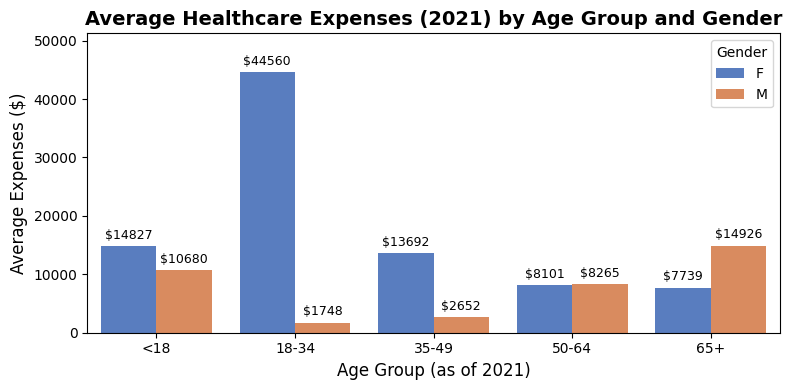

In [ ]:
profile_df_copy_1 = profile_df.copy()
# 2021 expenses → use age as of 2021 (one year ahead of the feature window)
profile_df_copy_1['AGE_2021'] = profile_df_copy_1['AGE_2020'] + 1
profile_df_copy_1['Age_Group'] = pd.cut(
    profile_df_copy_1['AGE_2021'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['<18', '18-34', '35-49', '50-64', '65+']
)
profile_df_copy_1 = profile_df_copy_1[['GENDER', 'RACE', 'Age_Group', 'EXPENSES_2021']]

expense_summary = profile_df_copy_1.groupby(
    ['Age_Group', 'GENDER'], observed=True
)['EXPENSES_2021'].mean().reset_index()

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=expense_summary, x='Age_Group', y='EXPENSES_2021',
                 hue='GENDER', palette='muted')
for container in ax.containers:
    ax.bar_label(container, fmt='$%0.0f', padding=3, fontsize=9)

plt.title('Average Healthcare Expenses (2021) by Age Group and Gender',
          fontsize=14, fontweight='bold')
plt.xlabel('Age Group (as of 2021)', fontsize=12)
plt.ylabel('Average Expenses ($)', fontsize=12)
plt.ylim(0, expense_summary['EXPENSES_2021'].max() * 1.15)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


The most striking finding is the dramatic expense spike among females aged 18–34 (avg. 44,560 USD), which is roughly 25 times higher than their male counterparts in the same group (1,748 USD), almost certainly driven by pregnancy and maternity-related costs during reproductive years. A similar female premium persists in the 35–49 group (13,692 vs. 2,652 USD), likely reflecting continued reproductive health and postpartum care. The gender gap narrows considerably in the 50–64 group (8,101 vs. 8,265 USD), where costs converge as reproductive factors diminish. The pattern fully reverses at 65+, where males average 14,926 USD compared to 7,739 USD for females, suggesting higher late-life chronic disease burden and surgical utilization among elderly men. These findings confirm that gender's effect on cost is strongly age-mediated, making the age–gender interaction a potentially important feature in downstream predictive modeling.

3.3 Complex Analysis: Coverage Gap Paradox: Historical Insurance Coverage Rate vs. Future Cost Risk

This section investigates whether a patient's historical insurance coverage rate predicts future cost risk. For each patient with prior medical activity in 2019–2020, a coverage rate is computed as the proportion of historical expenses reimbursed by the payer (HIST_TOTAL_COVERAGE / HIST_TOTAL_EXPENSES, capped at 1.0). Patients are then stratified into five tiers — No Prior Activity, Fully OOP, Low (1–49%), Moderate (50–84%), and High (≥85%) — and each tier is evaluated on two 2021 outcomes: the proportion of patients who crossed the high-cost threshold, and mean total expenses.

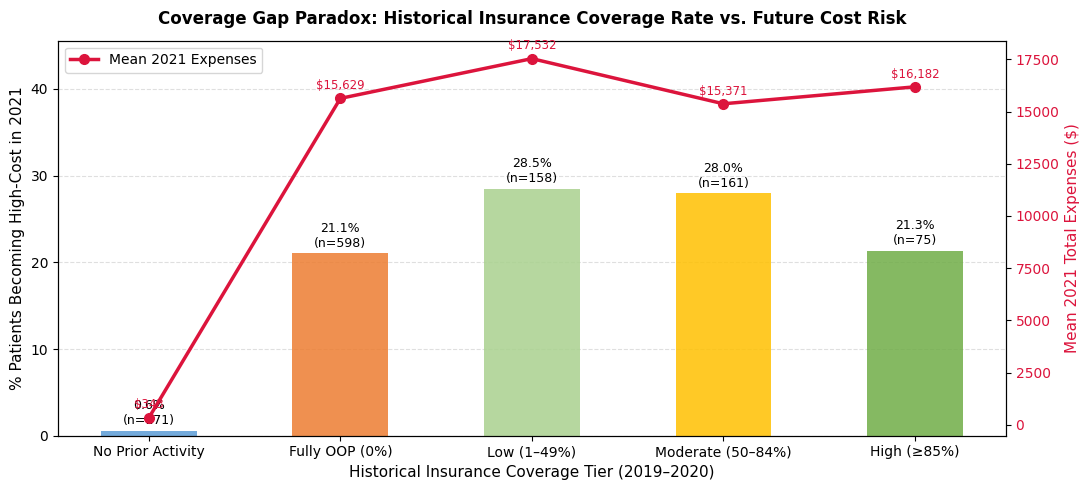

In [ ]:
df_33 = profile_df.copy()

# Coverage rate = what fraction of historical expenses was covered by payer
# Cap at 1.0 in case of payer over-payment edge cases
df_33['HIST_COVERAGE_RATE'] = np.where(
    df_33['HIST_TOTAL_EXPENSES'] > 0,
    (df_33['HIST_TOTAL_COVERAGE'] / df_33['HIST_TOTAL_EXPENSES']).clip(upper=1.0),
    np.nan
)

def assign_coverage_tier(row):
    if pd.isna(row['HIST_COVERAGE_RATE']):
        return 'No Prior Activity'
    elif row['HIST_COVERAGE_RATE'] == 0:
        return 'Fully OOP (0%)'
    elif row['HIST_COVERAGE_RATE'] < 0.5:
        return 'Low (1–49%)'
    elif row['HIST_COVERAGE_RATE'] < 0.85:
        return 'Moderate (50–84%)'
    else:
        return 'High (≥85%)'

df_33['COVERAGE_TIER'] = df_33.apply(assign_coverage_tier, axis=1)

tier_order = ['No Prior Activity', 'Fully OOP (0%)', 'Low (1–49%)',
              'Moderate (50–84%)', 'High (≥85%)']

summary_33 = df_33.groupby('COVERAGE_TIER', observed=True).agg(
    N=('PATIENT_ID', 'size'),
    HIGH_COST_RATE=('IS_HIGH_COST_2021', 'mean'),
    MEAN_EXPENSES_2021=('EXPENSES_2021', 'mean')
).reindex(tier_order).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))

colors = ['#5B9BD5', '#ED7D31', '#A9D18E', '#FFC000', '#70AD47']
bars = ax1.bar(summary_33['COVERAGE_TIER'],
               summary_33['HIGH_COST_RATE'] * 100,
               color=colors, alpha=0.85, width=0.5, zorder=2)

for bar, rate, n in zip(bars, summary_33['HIGH_COST_RATE'], summary_33['N']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             f'{rate*100:.1f}%\n(n={n})',
             ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('% Patients Becoming High-Cost in 2021', fontsize=11)
ax1.set_ylim(0, summary_33['HIGH_COST_RATE'].max() * 160)
ax1.set_xlabel('Historical Insurance Coverage Tier (2019–2020)', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)

ax2 = ax1.twinx()
ax2.plot(summary_33['COVERAGE_TIER'], summary_33['MEAN_EXPENSES_2021'],
         color='crimson', marker='o', linewidth=2.5, markersize=7,
         label='Mean 2021 Expenses', zorder=3)
for i, val in enumerate(summary_33['MEAN_EXPENSES_2021']):
    ax2.text(i, val + 300, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=8.5, color='crimson')

ax2.set_ylabel('Mean 2021 Total Expenses ($)', fontsize=11, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Coverage Gap Paradox: Historical Insurance Coverage Rate vs. Future Cost Risk',
          fontsize=12, fontweight='bold', pad=12)

lines, labels = ax2.get_legend_handles_labels()
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout()
plt.show()

The results reveal two non-obvious patterns. First, the "No Prior Activity" group (n=171) largely did not materialize as high-cost patients in 2021 — only 0.6% crossed the threshold — contradicting the intuitive pent-up demand hypothesis that healthcare-inactive patients accumulate deferred risk. Second, the highest-risk tier is not the fully uninsured but the partially covered: patients with Low (1–49%) coverage showed both the highest high-cost rate (28.5%) and the highest mean 2021 expenses (17,532 USD), slightly exceeding even the Moderate tier (28.0%, 15,371 USD). Counterintuitively, the Fully OOP group (completely uninsured, n=598) had a meaningfully lower high-cost rate (21.1%) than partially covered patients, suggesting that the uninsured may actively avoid expensive care, while partial coverage provides just enough of an incentive to engage with the healthcare system — but not enough to manage chronic conditions cost-effectively. This non-linear relationship between coverage level and future cost risk highlights coverage rate as a nuanced, non-monotonic risk signal worth including as a feature in predictive modeling.

3.4 Complex Analysis: SDOH vs. Clinical Conditions: Which Historical Diagnoses Best Predict Future High Cost?


This section investigates whether social determinants of health (SDOH) or clinical diagnoses are stronger predictors of future healthcare cost. For each of the top-10 historically diagnosed conditions, a risk lift is computed as the ratio of the 2021 high-cost rate among patients who had that condition versus those who did not. A lift above 1.0 means the condition is positively associated with becoming high-cost. Conditions are color-coded as SDOH (social and behavioral findings) or Clinical (medical disorders) to reveal whether the type of condition — not just its presence — carries predictive signal.

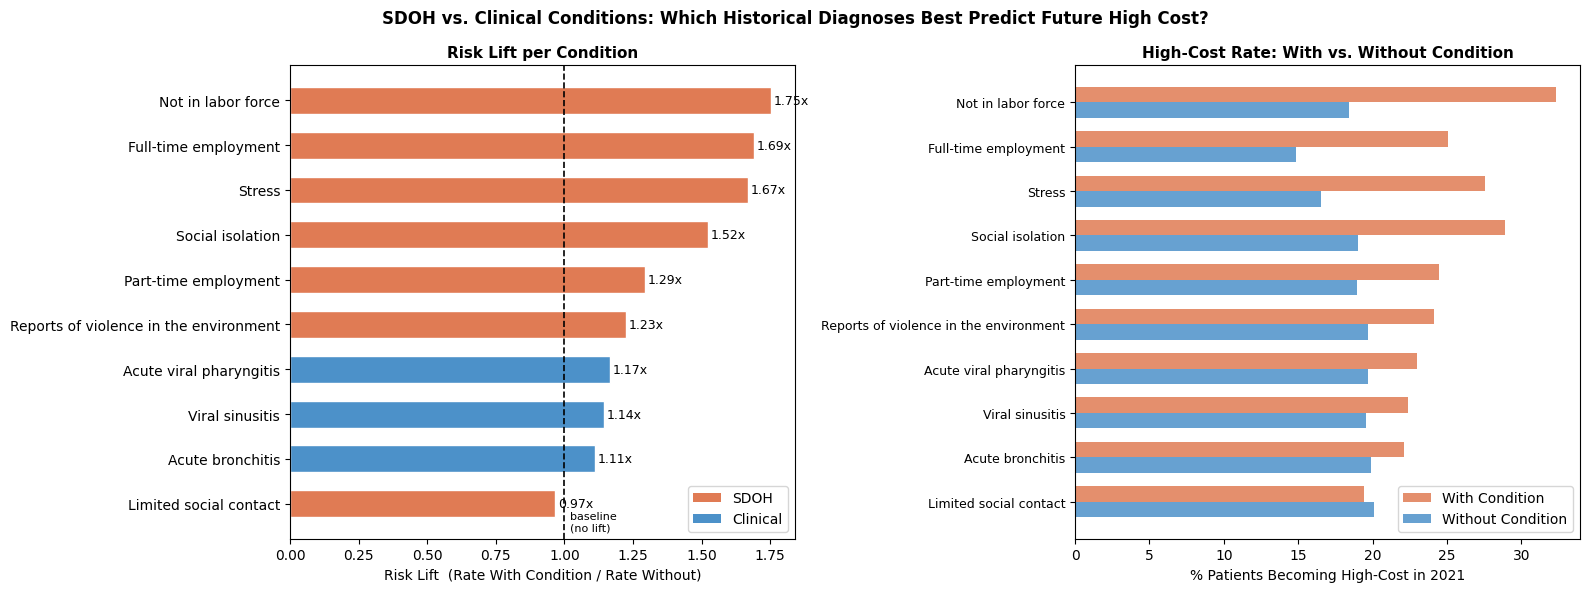

In [ ]:
# Extract the 10 binary condition columns and create clean readable labels
cond_cols   = [col for col in profile_df.columns if col.startswith('Hist_Condition_')]
cond_labels = [col.replace('Hist_Condition_', '').replace(' (finding)', '').replace(' (disorder)', '') for col in cond_cols]

# For each condition compute: high-cost rate and mean expenses for patients WITH vs. WITHOUT
records = []
for col, label in zip(cond_cols, cond_labels):
    has   = profile_df[profile_df[col] == 1]
    hasnt = profile_df[profile_df[col] == 0]
    rate_with    = has['IS_HIGH_COST_2021'].mean()
    rate_without = hasnt['IS_HIGH_COST_2021'].mean()
    records.append({
        'Condition'   : label,
        'N_With'      : len(has),
        'Rate_With'   : rate_with,
        'Rate_Without': rate_without,
        'Exp_With'    : has['EXPENSES_2021'].mean(),
        'Exp_Without' : hasnt['EXPENSES_2021'].mean(),
        'Risk_Lift'   : rate_with / rate_without if rate_without > 0 else np.nan
    })

df_34 = pd.DataFrame(records).sort_values('Risk_Lift', ascending=True).reset_index(drop=True)

# Tag each condition as SDOH (social determinant of health) or Clinical
sdoh_keywords = ['employment', 'stress', 'isolation', 'contact', 'labor', 'violence']
df_34['Type'] = df_34['Condition'].apply(
    lambda x: 'SDOH' if any(k in x.lower() for k in sdoh_keywords) else 'Clinical'
)

palette = {'SDOH': '#E07B54', 'Clinical': '#4C91C9'}
bar_colors = df_34['Type'].map(palette)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: risk lift — how much more likely a patient is to be high-cost if they had this condition
bars = axes[0].barh(df_34['Condition'], df_34['Risk_Lift'],
                    color=bar_colors, edgecolor='white', height=0.6)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.2)
axes[0].text(1.02, -0.6, 'baseline\n(no lift)', fontsize=8, color='black')
for bar, val in zip(bars, df_34['Risk_Lift']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}x', va='center', fontsize=9)
axes[0].set_xlabel('Risk Lift  (Rate With Condition / Rate Without)', fontsize=10)
axes[0].set_title('Risk Lift per Condition', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='#E07B54', label='SDOH'),
                         Patch(facecolor='#4C91C9', label='Clinical')], loc='lower right')

# Right panel: absolute high-cost rate side-by-side — with vs. without each condition
x     = np.arange(len(df_34))
width = 0.35
axes[1].barh(x + width / 2, df_34['Rate_With']    * 100, width,
             label='With Condition',    color='#E07B54', alpha=0.85)
axes[1].barh(x - width / 2, df_34['Rate_Without'] * 100, width,
             label='Without Condition', color='#4C91C9', alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_34['Condition'], fontsize=9)
axes[1].set_xlabel('% Patients Becoming High-Cost in 2021', fontsize=10)
axes[1].set_title('High-Cost Rate: With vs. Without Condition', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('SDOH vs. Clinical Conditions: Which Historical Diagnoses Best Predict Future High Cost?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The results are striking: all six conditions with the highest risk lift are SDOH factors, while all three clinical conditions (Acute bronchitis 1.11x, Viral sinusitis 1.14x, Acute viral pharyngitis 1.17x) cluster at the bottom of the ranking. "Not in labor force" carries the strongest signal at 1.75x — patients outside the workforce had a 32.3% high-cost rate versus 18.4% for those without that flag. A particularly non-obvious finding is that "Full-time employment" also ranks high at 1.69x: being employed does not reduce cost risk, likely because employer-sponsored insurance lowers the barrier to seeking care. Notably, both extremes of employment status ("Not in labor force" and "Full-time employment") elevate risk, while "Part-time employment" sits lower at 1.29x — suggesting a U-shaped relationship between employment stability and healthcare utilization. "Limited social contact" is the only condition below baseline (0.97x), possibly reflecting that socially isolated patients also avoid the healthcare system. Taken together, these findings challenge the assumption that clinical diagnoses are the most actionable cost predictors — chronic social and behavioral conditions carry equal or greater predictive weight.

3.5 Complex Analysis: Compound Risk: Does SDOH Burden Amplify the Coverage Gap Effect on Future Healthcare Cost?

This section synthesizes the findings from 3.3 and 3.4 by asking whether the two identified risk factors — SDOH burden and insurance coverage gap — compound each other in a non-additive way. Each patient is assigned a SDOH burden tier (None, Moderate, High) based on how many SDOH conditions they carried in 2019–2020, and a coverage tier recomputed from Section 3.3. A cross-tabulation then reveals the 2021 high-cost rate at every combination of the two dimensions. The significance of this analysis lies in its practical implication: if the two risk factors merely add together, addressing either one independently would be sufficient. But if they interact and amplify each other, it means a patient with both vulnerabilities needs simultaneous intervention — and a predictive model that ignores the interaction term will systematically underestimate risk for the most vulnerable group.

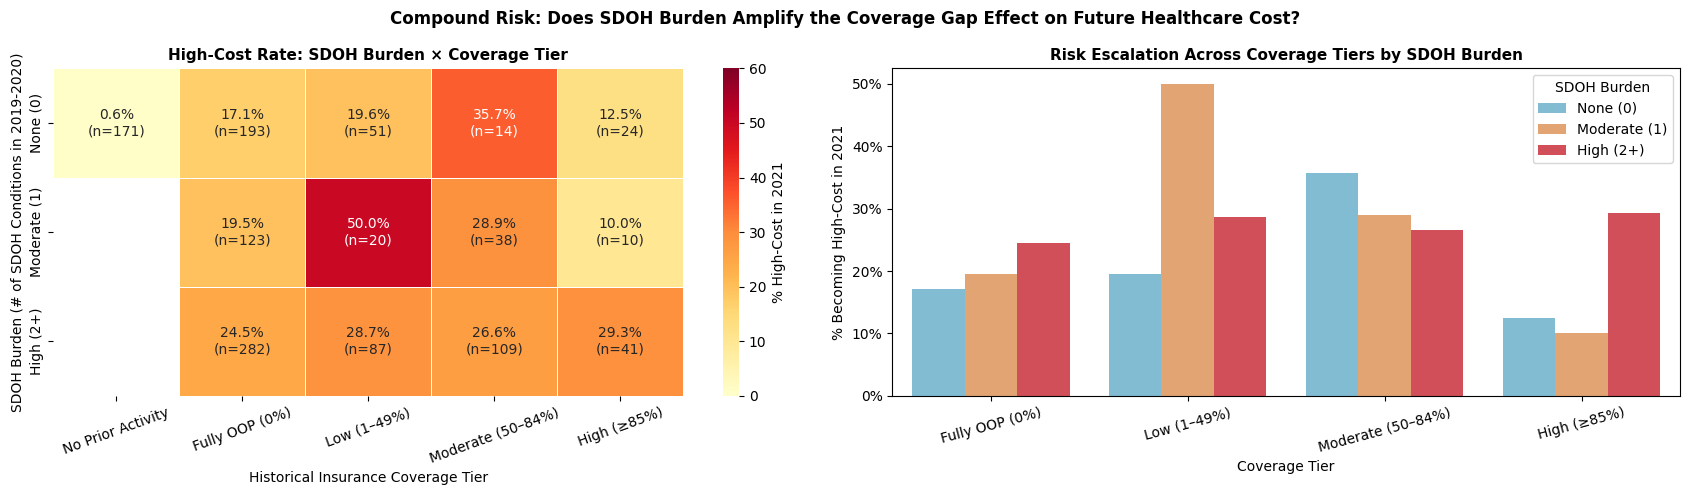

In [ ]:
df_35 = profile_df.copy()

# Reuse the same SDOH keyword list from 3.4 to identify SDOH condition columns
sdoh_keywords = ['employment', 'stress', 'isolation', 'contact', 'labor', 'violence']
sdoh_cols = [col for col in df_35.columns
             if col.startswith('Hist_Condition_') and
             any(k in col.lower() for k in sdoh_keywords)]

# Count how many distinct SDOH conditions each patient carried in 2019-2020
df_35['SDOH_COUNT'] = df_35[sdoh_cols].sum(axis=1)

# Group into three burden tiers: no SDOH, one, or two or more
df_35['SDOH_BURDEN'] = pd.cut(
    df_35['SDOH_COUNT'],
    bins=[-1, 0, 1, 10],
    labels=['None (0)', 'Moderate (1)', 'High (2+)']
)

# Recompute coverage rate and tier using the same logic as 3.3
df_35['HIST_COVERAGE_RATE'] = np.where(
    df_35['HIST_TOTAL_EXPENSES'] > 0,
    (df_35['HIST_TOTAL_COVERAGE'] / df_35['HIST_TOTAL_EXPENSES']).clip(upper=1.0),
    np.nan
)

def assign_coverage_tier(row):
    if pd.isna(row['HIST_COVERAGE_RATE']):
        return 'No Prior Activity'
    elif row['HIST_COVERAGE_RATE'] == 0:
        return 'Fully OOP (0%)'
    elif row['HIST_COVERAGE_RATE'] < 0.5:
        return 'Low (1–49%)'
    elif row['HIST_COVERAGE_RATE'] < 0.85:
        return 'Moderate (50–84%)'
    else:
        return 'High (≥85%)'

df_35['COVERAGE_TIER'] = df_35.apply(assign_coverage_tier, axis=1)

sdoh_order     = ['None (0)', 'Moderate (1)', 'High (2+)']
coverage_order = ['No Prior Activity', 'Fully OOP (0%)', 'Low (1–49%)', 'Moderate (50–84%)', 'High (≥85%)']

# Build pivot: rows = SDOH burden tier, cols = coverage tier, values = % high-cost
heatmap_data = df_35.groupby(
    ['SDOH_BURDEN', 'COVERAGE_TIER'], observed=True
)['IS_HIGH_COST_2021'].mean().unstack()
heatmap_data = heatmap_data.reindex(index=sdoh_order, columns=coverage_order)

# Build sample size table to annotate each cell with n
count_data = df_35.groupby(
    ['SDOH_BURDEN', 'COVERAGE_TIER'], observed=True
)['IS_HIGH_COST_2021'].count().unstack()
count_data = count_data.reindex(index=sdoh_order, columns=coverage_order)

# Combine rate and n into a single annotation string per cell
annot_data = heatmap_data.copy().astype(object)
for r in sdoh_order:
    for c in coverage_order:
        rate = heatmap_data.loc[r, c]
        n    = count_data.loc[r, c]
        annot_data.loc[r, c] = f'{rate*100:.1f}%\n(n={int(n)})' if pd.notna(rate) and pd.notna(n) else 'N/A'

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left panel: heatmap — darker cell = higher % of patients becoming high-cost in 2021
sns.heatmap(
    heatmap_data * 100,
    annot=annot_data, fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': '% High-Cost in 2021'},
    vmin=0, vmax=60
)
axes[0].set_title('High-Cost Rate: SDOH Burden × Coverage Tier', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Historical Insurance Coverage Tier', fontsize=10)
axes[0].set_ylabel('SDOH Burden (# of SDOH Conditions in 2019-2020)', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)

# Right panel: grouped bars — for each coverage tier, show how risk escalates as SDOH burden increases
plot_df = heatmap_data.reset_index().melt(
    id_vars='SDOH_BURDEN', value_name='HighCostRate', var_name='CoverageTier'
)
active_tiers = ['Fully OOP (0%)', 'Low (1–49%)', 'Moderate (50–84%)', 'High (≥85%)']
plot_df = plot_df[plot_df['CoverageTier'].isin(active_tiers)]

sns.barplot(
    data=plot_df, x='CoverageTier', y='HighCostRate',
    hue='SDOH_BURDEN', hue_order=sdoh_order,
    palette=['#74C2E1', '#F4A261', '#E63946'],
    order=active_tiers, ax=axes[1]
)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
axes[1].set_title('Risk Escalation Across Coverage Tiers by SDOH Burden', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Coverage Tier', fontsize=10)
axes[1].set_ylabel('% Becoming High-Cost in 2021', fontsize=10)
axes[1].legend(title='SDOH Burden')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Compound Risk: Does SDOH Burden Amplify the Coverage Gap Effect on Future Healthcare Cost?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


The results confirm a non-linear compounding effect, most starkly in the Moderate SDOH × Low Coverage cell, where 50.0% of patients became high-cost in 2021 — the single highest rate in the entire matrix (though note n=20, warranting caution). By contrast, patients with no SDOH burden at the same Low coverage tier reached only 19.6%, and patients with Moderate SDOH but full coverage dropped to 10.0%. This means the combination of even one SDOH condition and a coverage gap of 1–49% does not add risks linearly — it more than doubles the baseline. A second non-obvious finding emerges in the High SDOH (2+) row: risk remains persistently elevated at 24–29% regardless of coverage tier, suggesting that once SDOH burden reaches a critical threshold, insurance coverage alone can no longer offset it. Together, these patterns indicate that SDOH burden and coverage gap interact asymmetrically — moderate SDOH amplifies coverage-driven risk explosively, while high SDOH creates a coverage-resistant risk floor that insurance improvements alone cannot address.